In [1]:
import pandas as pd
import json
from globals import (
    BASE_DIR, 
    top_k_eval, 
    valid_popularity, 
    recommendation_dirpart, 
    full_eval_methods, 
    boosting_methods, 
    dynamic_methods,
    models_for_recbole
)
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.markers import MarkerStyle
from postprocess_baseline_top_k import dataset_metadata
from evaluation_metrics import (
    ndcg, 
    calculate_arp_poplift, 
    evaluation_user_group_means, 
    jensen_shannon, 
    jensen_shannon_per_user,
    per_user_distribution_stats,
    behavioral_ild_per_user, 
    geographic_ild_per_user,
)
from provider_reranker import build_item_similarity
from civic_reranker import load_coordinates
from platform_reranker import calculate_user_popularity_distributions
import pingouin as pg

dataset = "yelp" # perform for each dataset individually
valid_metrics = ["ndcg", "poplift", "ild", "geo_ild", "gini", "js"]
print(top_k_eval)

10


##  Define Functions

In [2]:
def process_top_k_json(input_file, output_file, k=10):
    """
    Process top-k recommendations from a JSON file, keeping only the item IDs for each user.
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    try:
        with open(input_file, "r") as infile:
            data = json.load(infile)

        top_k_result = {}
        for user_id, recommendations in data.items():
            if recommendations and isinstance(recommendations[0], dict):
                item_ids = recommendations[0]["item_id"][:k]
                top_k_result[user_id] = item_ids

        with open(output_file, "w") as outfile:
            json.dump(top_k_result, outfile, indent=4)
        print(f"Processed file saved to: {output_file}")
    
    except Exception as e:
        print(f"Error processing {input_file}: {e}")

In [3]:
def create_model_directories(dataset, data, base_dir, recommendation_dirpart):
    """
    Create output directories
    """
    model_directories = {}
    methods = full_eval_methods + boosting_methods + dynamic_methods

    def recommender_dir_combiner(dataset, modelpart, method):
        return os.path.join(base_dir, f"{dataset}_dataset", recommendation_dirpart, modelpart, method, "top_k_recommendations.json")

    for result in data:
        model_name = result["model"]
        model_directories[model_name] = {}
        
        for method in methods:
            model_directories[model_name][method] = recommender_dir_combiner(dataset, result["directory"], method)
    
    return model_directories

def open_ground_truth_user_group(dataset, valid_popularity=valid_popularity):
    """Perform data splitting and user group creation."""

    train_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.train.inter"), sep="\t")
    test_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.test.inter"), sep="\t")
    valid_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.valid.inter"), sep="\t")

    train_data = pd.concat([train_data, valid_data])
    user_group_dir = os.path.join(BASE_DIR, f"{dataset}_dataset", f"{dataset}_user_id_popularity.json")
    with open(user_group_dir) as f:
        user_groups = json.load(f)

    user_groups["HighPop"] = user_groups.pop("high")
    user_groups["LowPop"] = user_groups.pop("low")
    user_groups["MedPop"] = user_groups.pop("medium")



    checkin_df = train_data.copy()
    
    # Calculate item popularity
    value_counts = checkin_df["item_id:token"].value_counts().reset_index()
    value_counts.columns = ["item_id:token", "count"]
    value_counts[valid_popularity] = value_counts["count"] / len(value_counts)
    checkin_df = checkin_df.merge(
        value_counts[["item_id:token", valid_popularity]],
        on="item_id:token",
        how="left",
    )
    checkin_df.sort_values(by=valid_popularity, ascending=False, inplace=True)
    item_popularity = checkin_df.drop_duplicates(subset="item_id:token", keep="first")[
        ["item_id:token", valid_popularity]
    ]

    h_group = item_popularity.head(int(len(item_popularity) * 0.2))
    h_group["item_pop_group"] = "h"
    t_group = item_popularity.tail(int(len(item_popularity) * 0.2))
    t_group["item_pop_group"] = "t"
    m_group = item_popularity[
        ~item_popularity["item_id:token"].isin(h_group["item_id:token"]) &
        ~item_popularity["item_id:token"].isin(t_group["item_id:token"])
    ]
    m_group["item_pop_group"] = "m"

    item_popularity = pd.concat([h_group, m_group, t_group])
    item_popularity.sort_values(by=valid_popularity, inplace=True, ascending=False)

    upts = checkin_df.groupby("user_id:token")[valid_popularity].mean().reset_index()
    upts.columns = ["user_id:token", "upts"]
    return train_data, test_data, user_groups, item_popularity, upts


In [4]:
def unstack_recommendations(df):
    """Unstack the recommendations for each user into separate rows."""
    unstacked_df = df.explode(["item_id:token"]).reset_index(drop=True)
    return unstacked_df

In [5]:
def top_k_to_df(recommender_dir, top_k_eval=top_k_eval):
    """ Fixed version that handles nested lists """
    with open(recommender_dir) as f:
        data = json.load(f)
    
    base_recommendations = []
    
    for user, items in data.items():
        # FIX: Check if items is nested [[...]]
        if isinstance(items, list) and len(items) > 0 and isinstance(items[0], list):
            # Flatten: items = [[...]] -> items = [...]
            items = items[0]
        
        # Now iterate through individual items
        for item in items:
            base_recommendations.append({
                "user_id:token": user,
                "item_id:token": item
            })
    
    base_df = pd.DataFrame(base_recommendations)
    base_df = unstack_recommendations(base_df)
    df = base_df.groupby("user_id:token").head(top_k_eval)
    
    return df

In [6]:
def create_pop_distributions(data, item_popularity, user_groups):
    """Create a DataFrame with the distribution of item popularity for different user groups."""
    data = data.merge(item_popularity, on="item_id:token", how="left")
    g1 = data.loc[data["user_id:token"].isin(user_groups["HighPop"])].value_counts("item_pop_group", normalize=True).rename("g1")
    g2 = data.loc[data["user_id:token"].isin(user_groups["MedPop"])].value_counts("item_pop_group", normalize=True).rename("g2")
    g3 = data.loc[data["user_id:token"].isin(user_groups["LowPop"])].value_counts("item_pop_group", normalize=True).rename("g3")
    all = data.value_counts("item_pop_group", normalize=True).rename("all")
    distr_df = pd.DataFrame([g1, g2, g3, all]).fillna(0)
    distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True)
    return distr_df

In [7]:
def preprocess_distr(distr_df):
    """Preprocess the distribution DataFrame for plotting."""
    #distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True) # COMMENT IN FOR CALCULATING RESULTS, COMMENT OUT FOR PLOTTING
    data = distr_df.to_dict()
    result = []
    user_groups = data["h"].keys()

    for group in user_groups:
        h_value = data.get("h", {}).get(group, 0)
        m_value = data.get("m", {}).get(group, 0)
        t_value = data.get("t", {}).get(group, 0)
        
        result.append({
            "user_group": group,
            "h_ratio": h_value,
            "m_ratio": m_value,
            "t_ratio": t_value
        })

    return result


In [8]:
# Function for plotting popularity distribution (no legend inside this function)
def plot_popularity_distribution(ax, distr_df, label):
    """ Plot the popularity distribution of items for different user groups."""
    desired_order = ["LowPop", "MedPop", "HighPop", "All"]
    distr_df = distr_df.reindex(desired_order)
    colors = plt.cm.viridis([0.1, 0.5, 0.9])
    bars = distr_df.plot(kind="bar", stacked=True, ax=ax, color=colors, legend=False, edgecolor="black", linewidth=0, width=0.6)
    if label is not None:
        ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("User Groups")
    return distr_df


In [9]:
def calculate_t_test_between_user_groups(group_scores):
    """ Calculate t-test for two-sample t-test between low and high groups. 
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""
    
    ttest = {}
    # Conducting two-sample ttest
    result_low_high = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["HighPop"].values()),
                    correction=True)
    
    result_low_med = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["MedPop"].values()),
                    correction=True)
    
    ttest["low_high"] = float(result_low_high["p-val"])
    ttest["low_medium"] = float(result_low_med["p-val"])

    return ttest


In [10]:
def t_tests(group_scores, groups=("All", "HighPop", "MedPop", "LowPop")):
    variants = full_eval_methods + boosting_methods + dynamic_methods
    metrics = ["ndcg", "poplift", "ild", "geo_ild"]
    ttest_results = {}

    def clean(d):
        return [float(v) for v in d.values() if isinstance(v, (float, int))]

    for model_name, methods in group_scores.items():
        ttest_results[model_name] = {}

        for metric in metrics:
            ttest_results[model_name][metric] = {}

            for group in groups:
                ttest_results[model_name][metric][group] = {}

                baseline_vals = clean(
                    methods.get("baseline", {}).get(metric, {}).get(group, {})
                )

                for variant in variants:
                    variant_vals = clean(
                        methods.get(variant, {}).get(metric, {}).get(group, {})
                    )

                    if baseline_vals and variant_vals:
                        result = pg.ttest(baseline_vals, variant_vals, correction=True, paired=True)
                        ttest_results[model_name][metric][group][variant] = {
                            "p_val": float(result["p-val"].values[0]),
                            "delta": float(np.mean(variant_vals) - np.mean(baseline_vals)),
                        }
                    else:
                        ttest_results[model_name][metric][group][variant] = {
                            "p_val": None,
                            "delta": None,
                        }

    return ttest_results

In [11]:
def filter_to_group(general_results, ttest_rq2, metrics_to_keep, group="All"):
    """Filters data down to only the given user group and removes 'arp' before formatting."""
    filtered_data = {}


    for model in general_results:
        filtered_data[model] = {}

        for method in general_results[model]:
            if group not in general_results[model][method]:
                continue

            filtered_data[model][method] = {}

            for metric in metrics_to_keep:
                raw_val = general_results[model][method][group].get(metric)
                if raw_val is None:
                    continue

    
                t_data = None
                if method != "baseline" and metric in [
                    "ndcg",
                    "poplift",
                    "ild",
                    "geo_ild",
                ]:
                    try:
                        t_data = ttest_rq2[model][metric][group][method]
                    except KeyError:
                        pass

                filtered_data[model][method][metric] = {
                    "val": raw_val,
                    "t_test": t_data,
                }

    return filtered_data

In [12]:
from globals import fairness_agents
from evaluation_metrics import rank_biased_overlap, l1_half_norm


def load_user_top_k(json_file, k=top_k_eval):
    """Load a top-k recommendations JSON into {user_id: [item_ids]}, handling the
    occasional nested-list format also handled by top_k_to_df."""
    with open(json_file) as f:
        data = json.load(f)
    result = {}
    for user_id, items in data.items():
        if isinstance(items, list) and items and isinstance(items[0], list):
            items = items[0]
        result[user_id] = items[:k]
    return result


def compute_l1_half_fairness(methods, fairness_agents=fairness_agents, k=top_k_eval):
    """
    Post-hoc fairness evaluation: for each condition (method) in `methods`, compute
    each fairness agent's global mean RBO agreement (its own re-ranked list vs. the
    condition's delivered list, averaged over the whole run), then combine the
    per-agent m_bar values into the L1/2 norm -- rewards balanced agent satisfaction,
    not just a high average across agents.

    methods: {method_name: json_file_path}, as in model_dirs[model_name].
    Returns {method_name: {"m_bar": {agent: value}, "l1_half": value}}.
    """
    agent_recs = {agent: load_user_top_k(methods[agent], k=k) for agent in fairness_agents}

    l1_half_results = {}
    for method_name, json_file in methods.items():
        delivered_recs = load_user_top_k(json_file, k=k)

        m_bar = {}
        for agent in fairness_agents:
            scores = [
                rank_biased_overlap(agent_recs[agent][user_id], delivered_list, k=k)
                for user_id, delivered_list in delivered_recs.items()
                if user_id in agent_recs[agent] and agent_recs[agent][user_id] and delivered_list
            ]
            m_bar[agent] = float(np.mean(scores)) if scores else None

        l1_half_results[method_name] = {
            "m_bar": m_bar,
            "l1_half": l1_half_norm(m_bar) if all(v is not None for v in m_bar.values()) else None,
        }

    return l1_half_results

##  Run Main Evaluation

In [13]:
data = dataset_metadata(dataset, recommendation_dirpart)
model_dirs = create_model_directories(dataset, data, BASE_DIR, recommendation_dirpart)
train_data, test_data, user_groups, item_popularity, upts = open_ground_truth_user_group(dataset)
user_groups["All"] = user_groups["HighPop"] + user_groups["MedPop"] + user_groups["LowPop"]
ground_truth_distr = create_pop_distributions(train_data, item_popularity, user_groups)
poi_df = load_coordinates(dataset)
item_sim_matrix, item_idx = build_item_similarity(train_data)
total_catalog_size = train_data["item_id:token"].nunique()
item_coords = dict(zip(poi_df["item_id:token"], zip(poi_df["lat:float"], poi_df["lon:float"])))
distr_dict_ground_truth = preprocess_distr(ground_truth_distr)

# per-user h/m/t popularity profile (own check-in history), reused for per-user JSD below
train_data_with_pop = train_data.merge(item_popularity, on="item_id:token", how="left")
user_profiles = calculate_user_popularity_distributions(train_data_with_pop, item_popularity)

group_scores = {}
results = {}
ttest_results = {}

for model_name, methods in model_dirs.items():
    if model_name  == models_for_recbole[0]:
        results[model_name] = {}
        ttest_results[model_name] = {}
        group_scores[model_name] = {}

        for method_name, json_file in methods.items():  
            df = top_k_to_df(json_file)
            df_with_pop = df.merge(item_popularity, on="item_id:token", how="left")
            arp_scores, poplift_scores = calculate_arp_poplift(
                df_with_pop, item_popularity, upts, valid_popularity
            )

            per_user = {
                "ndcg":           ndcg(test_data=test_data, df=df, top_k_eval=top_k_eval),
                "arp":            arp_scores,
                "poplift":        poplift_scores,
                "ild":            behavioral_ild_per_user(df, item_sim_matrix, item_idx),
                "geo_ild":        geographic_ild_per_user(df, item_coords),
                "jsd_user":       jensen_shannon_per_user(user_profiles, df_with_pop),
            }
            
            distr_dict_recs = preprocess_distr(create_pop_distributions(df, item_popularity, user_groups))
            jsd_group = {
                group_gt["user_group"]: jensen_shannon(group_gt, group_recs)
                for group_gt, group_recs in zip(distr_dict_ground_truth, distr_dict_recs)
            }

            group_eval, per_user_by_group = evaluation_user_group_means(
                per_user, user_groups, df,
                total_catalog_size=total_catalog_size,
            )
            for group_name, jsd_value in jsd_group.items():
                group_eval.setdefault(group_name, {})["js"] = jsd_value


            group_scores[model_name][method_name] = per_user_by_group
            results[model_name][method_name] = group_eval

Loaded 4515 POI coordinates for dataset 'yelp'
Interaction matrix shape: (1500, 4432)
Item similarity matrix shape: (4432, 4432)


In [14]:
from evaluation_metrics import geo_distance_std_per_user, geo_distance_max_per_user

# per-user std dev and max of all-pairs haversine distance (km) between reviewed businesses
geo_std_per_user = geo_distance_std_per_user(train_data, item_coords)
geo_max_per_user = geo_distance_max_per_user(train_data, item_coords)

geo_spread_df = pd.DataFrame({
    "geo_std_km": geo_std_per_user,
    "geo_max_km": geo_max_per_user,
})
geo_spread_df.index.name = "user_id"
geo_spread_df.describe()

,geo_std_km,geo_max_km
count,1500.000000,1500.000000
mean,131.705015,340.573376
std,267.301616,662.408082
min,0.391250,1.647589
25%,4.026464,16.254393
50%,7.517816,28.521548
75%,17.203609,70.718987
max,1817.554937,3779.484741


In [15]:
rename_metrics = {"ndcg": "nDCG↑", "poplift" : "PopLift→0", "ild":"ILD↑", "geo_ild" : "GeoILD↓", "gini" : "Gini↓", "js" : "JSD↓"}
rename_methods = {"baseline" : "Baseline", 
                  "cp_min_js" : "Platform", 
                  "mmr" : "Provider", 
                  "geo" : "Civic", 
                  "borda" : "Borda", 
                  "schulze" : "Schulze", 
                  "borda2baseline" : "Borda-Baseline",
                  "borda2cp_min_js" : "Borda-Platform",
                  "borda2geo" : "Borda-Civic",
                  "borda2mmr" : "Borda-Provider",
                  "schulze2baseline" : "Schulze-Baseline",
                  "schulze2cp_min_js" : "Schulze-Platform",
                  "schulze2geo" : "Schulze-Civic",
                  "schulze2mmr" : "Schulze-Provider",
                  "borda_weighted" : "Borda-Weighted",
                  "schulze_weighted" : "Schulze-Weighted",
                  "borda_weighted_ci" : "Borda-Weighted-CI",
                  "schulze_weighted_ci" : "Schulze-Weighted-CI",
                  "borda_leastfair" : "Borda-LeastFair",
                  "schulze_leastfair" : "Schulze-LeastFair",
                  "borda_lottery" : "Borda-Lottery",
                  "borda_lottery_ci" : "Borda-Lottery-CI",
                  "schulze_lottery" : "Schulze-Lottery",
                  "schulze_lottery_ci" : "Schulze-Lottery-CI",
                  }

In [16]:
ttest_rq2 = t_tests(group_scores)

user_groups_to_report = ["All", "HighPop", "MedPop", "LowPop"]
filtered_results_by_group = {}
df_group_list = []  # <-- collect per-group dataframes here

for group in user_groups_to_report:
    filtered_results = filter_to_group(results, ttest_rq2, valid_metrics, group=group)
    filtered_results_by_group[group] = filtered_results

    rows = []
    for model, methods in filtered_results.items():
        for method, metrics in methods.items():
            row_data = {"model": model, "method": method}

            for metric, data in metrics.items():
                cur_val = data["val"]
                if method == "baseline":
                    row_data[metric] = f"{cur_val:.4f}"
                    if metric == "geo_ild":
                        row_data[metric] = f"{cur_val:.2f}"
                else:
                    delta_str = ""

                    if data["t_test"] and data["t_test"].get("p_val") is not None:
                        if data["t_test"]["p_val"] < (0.05 / (26 * 4)):
                            delta_str += "*"

                    if metric == "geo_ild":
                        row_data[metric] = f"{cur_val:.2f}{delta_str}"
                    else:
                        row_data[metric] = f"{cur_val:.4f}{delta_str}"

            rows.append(row_data)

    df_group = pd.DataFrame(rows).set_index(["model", "method"])
    df_group = df_group.rename(columns=rename_metrics, index=rename_methods)
    df_group.insert(0, "group", group)   # <-- tag rows with the group name

    df_group_list.append(df_group)

    print(f"\n{'='*60}\n{group} user group\n{'='*60}")
    print(df_group.to_string())
    print(df_group.to_latex(
        multirow=False,
        caption=f"Evaluation results for all methods across models ({group} user group)",
        label=f"tab:results_{group.lower()}",
        escape=False,
    ))

# Combined dataframe, all groups in one table
df_all_groups = pd.concat(df_group_list)

# Keep "filtered_results" pointing at the "All" group, for the plotting cells below that expect it
filtered_results = filtered_results_by_group["All"]

/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-package


All user group
                        group    nDCG↑ PopLift→0     ILD↑  GeoILD↓   Gini↓    JSD↓
model method                                                                      
BPR   Baseline            All   0.0419    2.0039   0.8129    21.72  0.9703  0.2545
      Platform            All  0.0338*   0.9643*  0.8677*    23.46  0.9281  0.0042
      Provider            All  0.0212*   0.2659*  0.9858*  111.14*  0.8533  0.0225
      Civic               All  0.0279*   0.8206*  0.8737*    0.61*  0.9323  0.0686
      Borda               All  0.0334*   1.2369*  0.8750*    7.40*  0.9304  0.1106
      Schulze             All  0.0339*   1.2815*  0.8697*   32.07*  0.9571  0.0914
      Borda-Baseline      All   0.0361   1.5090*  0.8529*    8.84*  0.9468  0.1656
      Borda-Platform      All  0.0351*   1.3802*  0.8603*    9.14*  0.9333  0.0861
      Borda-Civic         All  0.0336*   1.2588*  0.8657*    3.81*  0.9336  0.1097
      Borda-Provider      All  0.0279*   0.7900*  0.9142*   14.40*  0.9

In [17]:
df_group["group"] = group
df_group = df_group.set_index("group", append=True).reorder_levels(["group", "model", "method"])

In [18]:
# df_all_groups.to_csv(f"eval_all_groups_{dataset}")

In [19]:
l1_half_by_model = {
    model_name: compute_l1_half_fairness(methods)
    for model_name, methods in model_dirs.items()
    if model_name == models_for_recbole[0]
}

l1_half_rows = []
for model_name, method_results in l1_half_by_model.items():
    for method_name, vals in method_results.items():
        row = {"model": model_name, "method": method_name, "L1/2": vals["l1_half"]}
        for agent, m_bar_i in vals["m_bar"].items():
            row[f"m_bar[{rename_methods.get(agent, agent)}]"] = m_bar_i
        l1_half_rows.append(row)

df_l1_half = pd.DataFrame(l1_half_rows).set_index(["model", "method"])
df_l1_half = df_l1_half.rename(index=rename_methods)
print(f"\n{'='*60}\nL1/2 fairness norm (post-hoc, RBO-based)\n{'='*60}")
print(df_l1_half.to_string(float_format="%.4f"))

# Merge L1/2 into the main results table. It's a whole-run, cross-agent summary
# (not per user-subgroup), so it's only populated on the "All" group's rows;
# other groups (HighPop/MedPop/LowPop) get a blank in that column.
l1_half_flat = df_l1_half.reset_index()[["model", "method", "L1/2"]].copy()
l1_half_flat["L1/2"] = l1_half_flat["L1/2"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")
l1_half_flat["group"] = "All"

df_all_groups = df_all_groups.reset_index().merge(
    l1_half_flat, on=["group", "model", "method"], how="left"
)
df_all_groups["L1/2"] = df_all_groups["L1/2"].fillna("")
df_all_groups = df_all_groups.set_index(["group", "model", "method"])

# re-save with the merged column
df_all_groups.to_csv(f"eval_all_groups_{dataset}")

df_all_groups



L1/2 fairness norm (post-hoc, RBO-based)
                          L1/2  m_bar[Platform]  m_bar[Civic]  m_bar[Provider]
model method                                                                  
BPR   Baseline          0.3916           0.5151        0.3818           0.2935
      Platform          0.4659           1.0000        0.3005           0.2495
      Provider          0.4656           0.2495        0.2998           1.0000
      Civic             0.4880           0.3005        1.0000           0.2998
      Borda             0.3656           0.3604        0.4231           0.3170
      Schulze           0.3967           0.4945        0.3988           0.3077
      Borda-Baseline    0.3707           0.3849        0.4279           0.3046
      Borda-Platform    0.3876           0.4299        0.4268           0.3121
      Borda-Civic       0.3837           0.3604        0.4890           0.3120
      Borda-Provider    0.3480           0.3132        0.3695           0.3626
      Schu

nDCG↑ PopLift→0     ILD↑  GeoILD↓   Gini↓  \
group  model method                                                           
All    BPR   Baseline            0.0419    2.0039   0.8129    21.72  0.9703   
             Platform           0.0338*   0.9643*  0.8677*    23.46  0.9281   
             Provider           0.0212*   0.2659*  0.9858*  111.14*  0.8533   
             Civic              0.0279*   0.8206*  0.8737*    0.61*  0.9323   
             Borda              0.0334*   1.2369*  0.8750*    7.40*  0.9304   
...                                 ...       ...      ...      ...     ...   
LowPop BPR   Schulze-Weighted    0.0203   1.0296*  0.8725*    31.65  0.9548   
             Borda-LeastFair     0.0187   0.9274*  0.8888*   44.41*  0.9003   
             Schulze-LeastFair   0.0268   0.6009*  0.9046*   68.47*  0.8849   
             Borda-Lottery       0.0243   1.0017*  0.8780*    27.19  0.9068   
             Schulze-Lottery     0.0268   0.6279*  0.9042*   76.04*  0.8789   

                                  JSD↓    L1/2  
group  model method                             
All    BPR   Baseline           0.2545  0.3916  
             Platform           0.0042  0.4659  
             Provider           0.0225  0.4656  
             Civic              0.0686  0.4880  
             Borda              0.1106  0.3656  
...                                ...     ...  
LowPop BPR   Schulze-Weighted   0.0669          
             Borda-LeastFair    0.0710          
             Schulze-LeastFair  0.0069          
             Borda-Lottery      0.0726          
             Schulze-Lottery    0.0090          

[80 rows x 7 columns]

## Per-user distributional fairness (complementary to mean-based L1/2)

L1/2 above is a whole-run, cross-agent *mean* balance score. It's a good primary metric, but a
mean can hide a long worst-case tail for individual users. The two cells below report
median/std/min/max per condition per metric, and visualize the full per-user distribution
with a violin+boxplot per condition, so a pattern like a long JSD tail for a specific
condition (e.g. Schulze-LeastFair) is visible directly rather than buried in a table.

In [20]:
model_name = models_for_recbole[0]

dist_metrics = ["ild", "geo_ild", "jsd_user", "poplift"]
local_rename_metrics = {**rename_metrics, "jsd_user": "JSD (per-user)\u2193"}

dist_rows = []
for method_name in model_dirs[model_name]:
    if method_name not in group_scores[model_name]:
        continue
    stats = per_user_distribution_stats(group_scores[model_name][method_name])
    group_stats = stats.get("All", {})
    for metric in dist_metrics:
        if metric not in group_stats:
            continue
        row = {
            "method": method_name,
            "metric": metric,
            "mean": results[model_name][method_name]["All"].get(metric),
        }
        row.update(group_stats[metric])
        dist_rows.append(row)

df_dist_stats = pd.DataFrame(dist_rows)
df_dist_stats["method"] = df_dist_stats["method"].map(lambda m: rename_methods.get(m, m))
df_dist_stats["metric"] = df_dist_stats["metric"].map(lambda m: local_rename_metrics.get(m, m))
df_dist_stats = df_dist_stats.set_index(["metric", "method"]).sort_index()

print(f"\n{'='*60}\nPer-user distributional stats (complementary to L1/2 and group means)\n{'='*60}")
print(df_dist_stats.to_string(float_format="%.4f"))
df_dist_stats



Per-user distributional stats (complementary to L1/2 and group means)
                                      mean  median      std     min       max
metric          method                                                       
GeoILD↓         Baseline           21.7209  5.4242 101.1592  0.4176 1763.5390
                Borda               7.3974  2.2460  46.0091  0.2154  956.1935
                Borda-Baseline      8.8356  2.5213  58.1478  0.2373 1174.7069
                Borda-Civic         3.8085  1.2366  28.1481  0.1628  613.4980
                Borda-LeastFair    39.3112  6.0453 148.5735  0.1241 2034.0547
                Borda-Lottery      28.0941  4.4729 118.4332  0.1241 1765.2797
                Borda-Platform      9.1400  2.7502  58.3881  0.2373 1174.7069
                Borda-Provider     14.3986  3.9861  74.5715  0.4832 1542.0276
                Borda-Weighted      9.3063  2.6565  58.9502  0.2302 1174.1156
                Civic               0.6081  0.3216   0.6937  0.0507    

mean    median         std       min  \
metric    method                                                         
GeoILD↓   Baseline           21.720937  5.424173  101.159246  0.417616   
          Borda               7.397364  2.245986   46.009076  0.215446   
          Borda-Baseline      8.835643  2.521252   58.147767  0.237308   
          Borda-Civic         3.808467  1.236569   28.148073  0.162778   
          Borda-LeastFair    39.311222  6.045299  148.573461  0.124097   
...                                ...       ...         ...       ...   
PopLift→0 Schulze-LeastFair   0.672828  0.480770    0.762474 -0.532353   
          Schulze-Lottery     0.684359  0.507937    0.750523 -0.601190   
          Schulze-Platform    0.845173  0.708804    0.710741 -0.413235   
          Schulze-Provider    0.691050  0.557874    0.719999 -0.494048   
          Schulze-Weighted    1.278031  1.092665    0.961634 -0.391176   

                                     max  
metric    method                          
GeoILD↓   Baseline           1763.539002  
          Borda               956.193530  
          Borda-Baseline     1174.706885  
          Borda-Civic         613.497973  
          Borda-LeastFair    2034.054707  
...                                  ...  
PopLift→0 Schulze-LeastFair     5.120192  
          Schulze-Lottery       5.120192  
          Schulze-Platform      4.109722  
          Schulze-Provider      3.907143  
          Schulze-Weighted      5.069565  

[80 rows x 5 columns]

In [21]:
['baseline',
 'cp_min_js',
 'mmr',
 'geo',
 'schulze',
 'schulze_weighted',
 'schulze_leastfair',
 'schulze_lottery',
 'borda',
 'borda_weighted',
 'borda_leastfair',
 'borda_lottery',
]

['baseline',
 'cp_min_js',
 'mmr',
 'geo',
 'schulze',
 'schulze_weighted',
 'schulze_leastfair',
 'schulze_lottery',
 'borda',
 'borda_weighted',
 'borda_leastfair',
 'borda_lottery']

In [22]:
group_scores["BPR"]["baseline"].keys()

dict_keys(['ndcg', 'arp', 'poplift', 'ild', 'geo_ild', 'jsd_user'])

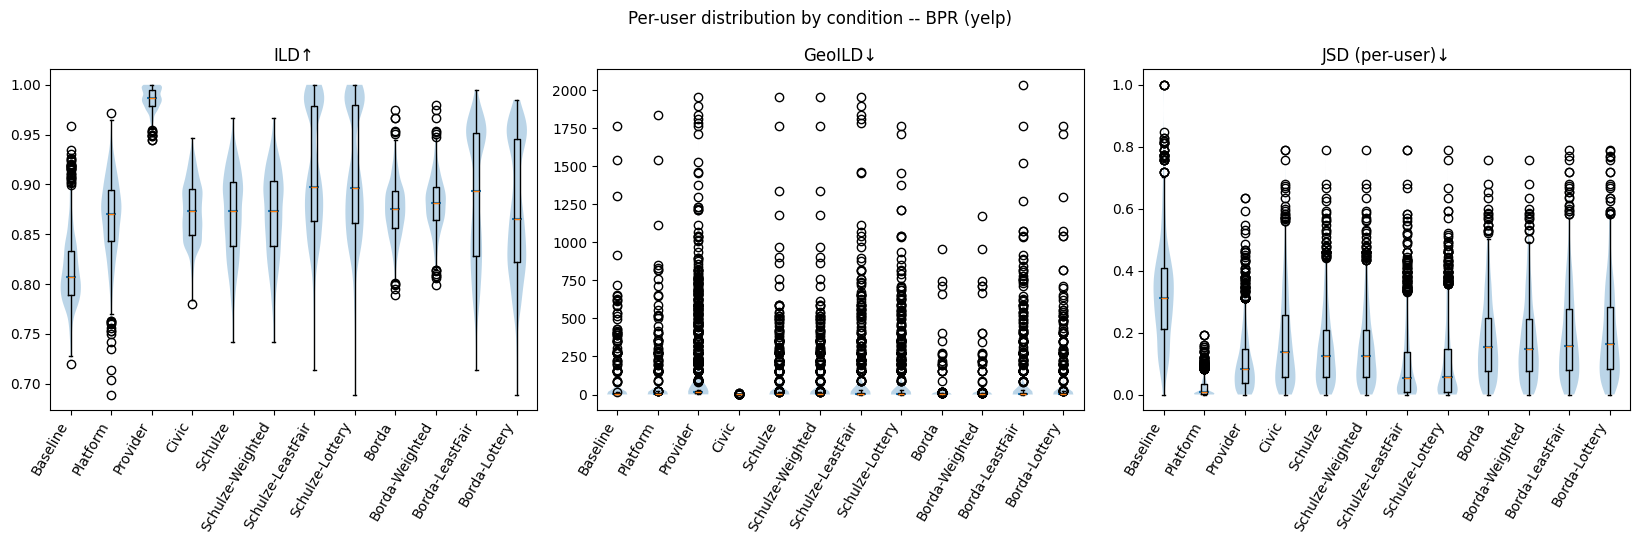

In [23]:
plot_metrics = ["ild", "geo_ild", "jsd_user"]
# plot_methods = [m for m in model_dirs[model_name] if m in group_scores[model_name]]
plot_methods = ['baseline',
 'cp_min_js',
 'mmr',
 'geo',
 'schulze',
 'schulze_weighted',
 'schulze_leastfair',
 'schulze_lottery',
 'borda',
 'borda_weighted',
 'borda_leastfair',
 'borda_lottery',
]

fig, axs = plt.subplots(1, len(plot_metrics), figsize=(5.5 * len(plot_metrics), 5.5))

for ax, metric in zip(axs, plot_metrics):
    data, labels = [], []
    for method_name in plot_methods:
        scores = group_scores[model_name][method_name].get(metric, {}).get("All", {})
        if not scores:
            continue
        data.append(list(scores.values()))
        labels.append(rename_methods.get(method_name, method_name))

    positions = range(1, len(labels) + 1)
    ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    ax.boxplot(data, positions=positions, widths=0.15, showfliers=True)
    ax.set_xticks(list(positions))
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_title(local_rename_metrics.get(metric, metric))

fig.suptitle(f"Per-user distribution by condition -- {model_name} ({dataset})")
fig.tight_layout()

plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_statistics.png"), bbox_inches="tight")
plt.show()


In [24]:
# --- Second, independent L1/2: outcome-based m_bar instead of RBO-based m_bar. ---
# For each condition already in `results` (same rows as the RBO-based L1/2 above),
# take its whole-run raw ILD / GeoILD / JSD ("All" group) and normalize each metric
# against a fixed EXTERNAL bound (not derived from whichever conditions happen to
# be in this table, unlike min-max):
#   - JSD is bounded [0,1] by construction (log2-based Jensen-Shannon divergence),
#     so the raw value already IS the normalized value -- no division needed.
#   - ILD is bounded [0,1] by construction too, since build_item_similarity uses
#     cosine similarity over non-negative (log1p-of-checkin-count) vectors, so
#     similarity in [0,1] and ILD = 1 - similarity in [0,1] -- also no division.
#   - GeoILD has no universal bound (raw km, scale depends on the dataset's own
#     geographic extent), so it's divided by max_pairwise_haversine(item_coords),
#     precomputed once per dataset via compute_geo_bounds.py.
# Then oriented the same direction as m_i (higher = more satisfied): ILD as-is,
# 1 - normalized GeoILD, 1 - JSD.
#
# If Schulze-LeastFair/Lottery also land near the top here, that's evidence the
# RBO-based balance reflects genuine delivered-outcome fairness, not just
# self-referential convergence (agents agreeing with an output because it's
# similar to their own list, regardless of whether it's actually diverse/local/
# on-profile). If the two L1/2s disagree, RBO-agreement parity and actual
# outcome parity are different things.

import warnings

from compute_geo_bounds import load_max_geo_distance

model_name = models_for_recbole[0]  # don't rely on leftover loop state from earlier cells
max_geo_distance = load_max_geo_distance(dataset)  # km, precomputed once per dataset
assert max_geo_distance > 0, f"max_geo_distance for {dataset} is {max_geo_distance} (<= 0)"


def _clip01(v, label=""):
    """Clip to [0,1], but warn first if a value is out of range by more than
    floating-point noise -- that's a sign of a real upstream bug (e.g. a
    similarity measure that isn't actually bounded the way it's assumed to be),
    not something that should get silently absorbed into a clean-looking 1.0."""
    if v is not None and (v > 1.01 or v < -0.01):
        warnings.warn(f"{label} raw value {v} is out of the expected [0,1] range before clipping")
    return None if v is None else min(max(v, 0.0), 1.0)

raw_ild = {m: results[model_name][m]["All"].get("ild") for m in model_dirs[model_name]}
raw_geo_ild = {m: results[model_name][m]["All"].get("geo_ild") for m in model_dirs[model_name]}
raw_jsd = {m: results[model_name][m]["All"].get("js") for m in model_dirs[model_name]}

norm_ild = {m: _clip01(v, label=f"ild[{m}]") for m, v in raw_ild.items()}
norm_geo_ild = {
    m: _clip01(None if v is None else v / max_geo_distance, label=f"geo_ild[{m}]")
    for m, v in raw_geo_ild.items()
}
norm_jsd = {m: _clip01(v, label=f"jsd[{m}]") for m, v in raw_jsd.items()}

l1_half_outcome_rows = []
for m in model_dirs[model_name]:
    m_bar_outcome = {
        "mmr": norm_ild[m],
        "geo": None if norm_geo_ild[m] is None else 1 - norm_geo_ild[m],
        "cp_min_js": None if norm_jsd[m] is None else 1 - norm_jsd[m],
    }
    l1_half = (
        l1_half_norm(m_bar_outcome)
        if all(v is not None for v in m_bar_outcome.values())
        else None
    )
    row = {"model": model_name, "method": m, "L1/2 (outcome)": l1_half}
    for agent, v in m_bar_outcome.items():
        row[f"m_bar_outcome[{rename_methods.get(agent, agent)}]"] = v
    l1_half_outcome_rows.append(row)

df_l1_half_outcome = pd.DataFrame(l1_half_outcome_rows).set_index(["model", "method"])
df_l1_half_outcome = df_l1_half_outcome.rename(index=rename_methods)
print(f"\n{'='*60}\nL1/2 fairness norm (post-hoc, OUTCOME-based: ILD/GeoILD/JSD)\n{'='*60}")
print(df_l1_half_outcome.to_string(float_format="%.4f"))

# side-by-side comparison, ranked by the RBO-based L1/2
l1_half_comparison = df_l1_half[["L1/2"]].rename(columns={"L1/2": "L1/2 (RBO)"}).join(
    df_l1_half_outcome[["L1/2 (outcome)"]]
)
l1_half_comparison["rank (RBO)"] = l1_half_comparison["L1/2 (RBO)"].rank(ascending=False)
l1_half_comparison["rank (outcome)"] = l1_half_comparison["L1/2 (outcome)"].rank(ascending=False)
l1_half_comparison["rank_delta"] = (
    l1_half_comparison["rank (RBO)"] - l1_half_comparison["rank (outcome)"]
)

print(f"\n{'='*60}\nRBO-based vs outcome-based L1/2 comparison\n{'='*60}")
print(l1_half_comparison.sort_values("rank (RBO)").to_string(float_format="%.4f"))
l1_half_comparison



L1/2 fairness norm (post-hoc, OUTCOME-based: ILD/GeoILD/JSD)
                         L1/2 (outcome)  m_bar_outcome[Provider]  m_bar_outcome[Civic]  m_bar_outcome[Platform]
model method                                                                                                   
BPR   Baseline                   0.8039                   0.8129                0.8552                   0.7455
      Platform                   0.9012                   0.8677                0.8436                   0.9958
      Provider                   0.6892                   0.9858                0.2591                   0.9775
      Civic                      0.9330                   0.8737                0.9959                   0.9314
      Borda                      0.9047                   0.8750                0.9507                   0.8894
      Schulze                    0.8541                   0.8697                0.7862                   0.9086
      Borda-Baseline             0.8755   

L1/2 (RBO)  L1/2 (outcome)  rank (RBO)  \
model method                                                      
BPR   Baseline             0.391614        0.803891        10.0   
      Platform             0.465885        0.901160         4.0   
      Provider             0.465611        0.689188         5.0   
      Civic                0.487993        0.933022         3.0   
      Borda                0.365550        0.904745        16.0   
      Schulze              0.396664        0.854051         8.0   
      Borda-Baseline       0.370660        0.875514        15.0   
      Borda-Platform       0.387569        0.904133        11.0   
      Borda-Civic          0.383656        0.909601        12.0   
      Borda-Provider       0.347970        0.915672        18.0   
      Schulze-Baseline     0.383106        0.826314        13.0   
      Schulze-Platform     0.370963        0.879613        14.0   
      Schulze-Civic        0.316949        0.816784        19.0   
      Schulze-Provider     0.306943        0.817750        20.0   
      Borda-Weighted       0.361113        0.903620        17.0   
      Schulze-Weighted     0.400972        0.854850         7.0   
      Borda-LeastFair      0.395804        0.837278         9.0   
      Schulze-LeastFair    0.520660        0.857410         2.0   
      Borda-Lottery        0.401366        0.857936         6.0   
      Schulze-Lottery      0.521977        0.859230         1.0   

                         rank (outcome)  rank_delta  
model method                                         
BPR   Baseline                     19.0        -9.0  
      Platform                      7.0        -3.0  
      Provider                     20.0       -15.0  
      Civic                         1.0         2.0  
      Borda                         4.0        12.0  
      Schulze                      14.0        -6.0  
      Borda-Baseline                9.0         6.0  
      Borda-Platform                5.0         6.0  
      Borda-Civic                   3.0         9.0  
      Borda-Provider                2.0        16.0  
      Schulze-Baseline             16.0        -3.0  
      Schulze-Platform              8.0         6.0  
      Schulze-Civic                18.0         1.0  
      Schulze-Provider             17.0         3.0  
      Borda-Weighted                6.0        11.0  
      Schulze-Weighted             13.0        -6.0  
      Borda-LeastFair              15.0        -6.0  
      Schulze-LeastFair            12.0       -10.0  
      Borda-Lottery                11.0        -5.0  
      Schulze-Lottery              10.0        -9.0

## Plots

In [25]:
print(metrics)

{'ndcg': {'val': 0.026818594882491442, 't_test': {'p_val': 0.2944660826942913, 'delta': 0.004669168212982695}}, 'poplift': {'val': 0.6279316119574471, 't_test': {'p_val': 1.604698269276552e-46, 'delta': -1.142316632531943}}, 'ild': {'val': 0.9041926277078847, 't_test': {'p_val': 1.941890862277731e-63, 'delta': 0.0918117303908289}}, 'geo_ild': {'val': 76.03539504318644, 't_test': {'p_val': 1.1850426912662007e-08, 'delta': 64.75169830391168}}, 'gini': {'val': 0.8789028279181708, 't_test': None}, 'js': {'val': 0.008996159800559065, 't_test': None}}


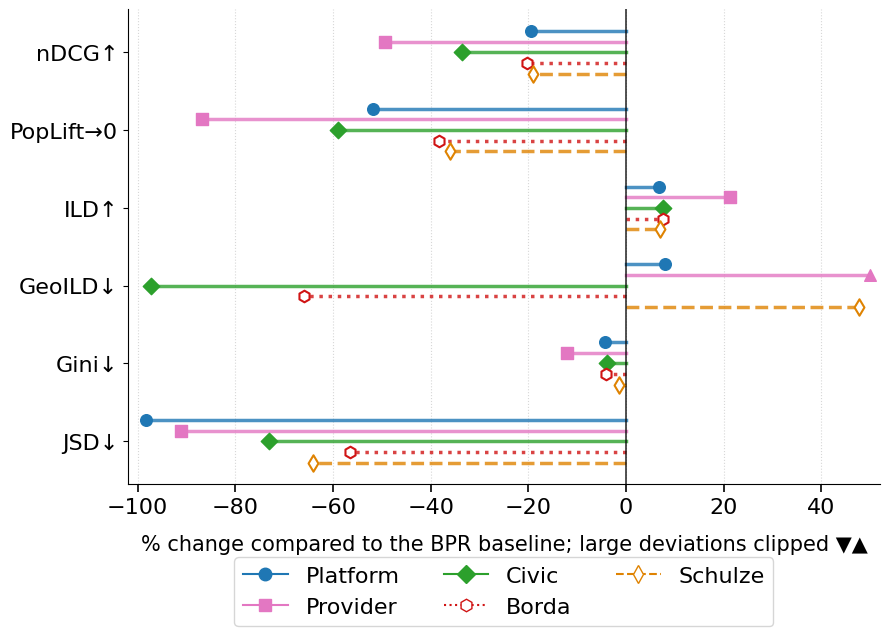

In [26]:
model_to_plot = models_for_recbole[0]
variant_styles = {
    "cp_min_js": {"color": "#1f77b4", "ls": "-", "marker": "o", "fill": "full", "label": "Platform"},
    "mmr": {"color": "#e377c2", "ls": "-", "marker": "s", "fill": "fill", "label": "Provider"},
    "geo": {"color": "#2ca02c", "ls": "-", "marker": "D", "fill": "full", "label": "Civic"},
    "borda": {"color": "#d01414", "ls": ":", "marker": "h", "fill": "none", "label": "Borda"},
    "schulze": {"color": "#df8302", "ls": "--", "marker": "d", "fill": "none", "label": "Schulze"},

}

rows = []
baseline_data = filtered_results[model_to_plot]["baseline"]

# Enforce loop consistency by utilizing the explicit list ordering
methods_keys = [m for m in variant_styles.keys() if m in filtered_results[model_to_plot]]

for method in methods_keys:
    delta = {}
    for m in valid_metrics:
        base_val = baseline_data[m]["val"]
        curr_val = filtered_results[model_to_plot][method][m]["val"]
        delta[m] = ((curr_val - base_val) / abs(base_val)) * 100 if base_val != 0 else 0

    delta["method"] = method
    rows.append(delta)

rel_df = pd.DataFrame(rows).set_index("method")
metric_labels = [rename_metrics.get(m, m) for m in valid_metrics]
fig, ax = plt.subplots(figsize=(9, 6.5))
CLIP_low = 100
CLIP_high = 50
Y_SPACING = 0.4
y_pos = np.arange(len(valid_metrics)) * Y_SPACING
n_methods = len(methods_keys)

for i, method in enumerate(methods_keys):
    vals = rel_df.loc[method, valid_metrics].values
    style = variant_styles[method]
    
    color = style["color"]
    ls = style["ls"]
    m_type = style["marker"]

    offset = (i - n_methods / 2 + 0.5) * 0.055

    for j, val in enumerate(vals):
        y = y_pos[j] + offset
        clipped = np.clip(val, -CLIP_low, CLIP_high)
        final_marker = "^" if val > CLIP_high else ("v" if val < -CLIP_low else m_type)
        ax.plot([0, clipped], [y, y], color=color, linestyle=ls, lw=2.5, alpha=0.8)

        if style["fill"] == "none" and final_marker == m_type:
            ax.scatter(clipped, y, edgecolor=color, facecolor="white", s=70, zorder=3, marker=final_marker, lw=1.5)
        elif style["fill"] == "left" and final_marker == m_type:
            ax.scatter(clipped, y, s=70, zorder=3, marker=MarkerStyle(final_marker, fillstyle="left"), color=color)
        else:
            ax.scatter(clipped, y, color=color, s=70, zorder=3, marker=final_marker, alpha=1.0)

ax.axvline(0, color="black", lw=1.2, ls="-", alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(metric_labels, fontsize=16)
ax.invert_yaxis()

ax.set_xlabel("% change compared to the BPR baseline; large deviations clipped ▼▲", fontsize=15, labelpad=12)
ax.set_xlim(-CLIP_low-2, CLIP_high+2)
ax.tick_params(axis="x", labelsize=16, length=6, width=1.2)
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = []
for m in methods_keys:
    style = variant_styles[m]
    label_text = style["label"]

    if style["fill"] == "none":
        handle = mlines.Line2D([], [], color=style["color"], linestyle=style["ls"], 
                               marker=style["marker"], markerfacecolor="white", markeredgecolor=style["color"],
                               markersize=9, lw=1.5, label=label_text)
    elif style["fill"] == "left":
        handle = mlines.Line2D([], [], color=style["color"], linestyle=style["ls"], 
                               marker=style["marker"], markerfacecolor=style["color"], markeredgecolor=style["color"],
                               fillstyle="left", markersize=9, lw=1.5, label=label_text)
    else:
        handle = mlines.Line2D([], [], color=style["color"], linestyle=style["ls"], 
                               marker=style["marker"], markerfacecolor=style["color"],
                               markersize=9, lw=1.5, label=label_text)
    legend_handles.append(handle)

ax.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.13),
    frameon=True,
    fontsize=16,
)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_metrics_percentage_change.png"), bbox_inches="tight", dpi=300)
plt.show()

In [27]:
# Additional Config for a Relative Plot including the weighted experiments

# variant_styles_full_plot = {
#     "cp_min_js": {"color": "#1f77b4", "ls": "-", "marker": "o", "fill": "full", "label": "Platform"},
#     "mmr": {"color": "#e377c2", "ls": "-", "marker": "s", "fill": "full", "label": "Provider"},
#     "geo": {"color": "#2ca02c", "ls": "-", "marker": "D", "fill": "full", "label": "Civic"},
    
#     "borda": {"color": "#d87192", "ls": "-", "marker": "h", "fill": "full", "label": "Borda"},
#     "schulze": {"color": "#df8302", "ls": "-", "marker": "d", "fill": "full", "label": "Schulze"},

#     "borda2baseline": {"color": "#7f7f7f", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-User"},
#     "borda2cp_min_js": {"color": "#1f77b4", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-Platform"},
#     "borda2mmr": {"color": "#e377c2", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-Provider"},
#     "borda2geo": {"color": "#2ca02c", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-Civic"},

#     "schulze2baseline": {"color": "#7f7f7f", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-User"},
#     "schulze2cp_min_js": {"color": "#1f77b4", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-Platform"},
#     "schulze2mmr": {"color": "#e377c2", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-Provider"},
#     "schulze2geo": {"color": "#2ca02c", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-Civic"},

# }

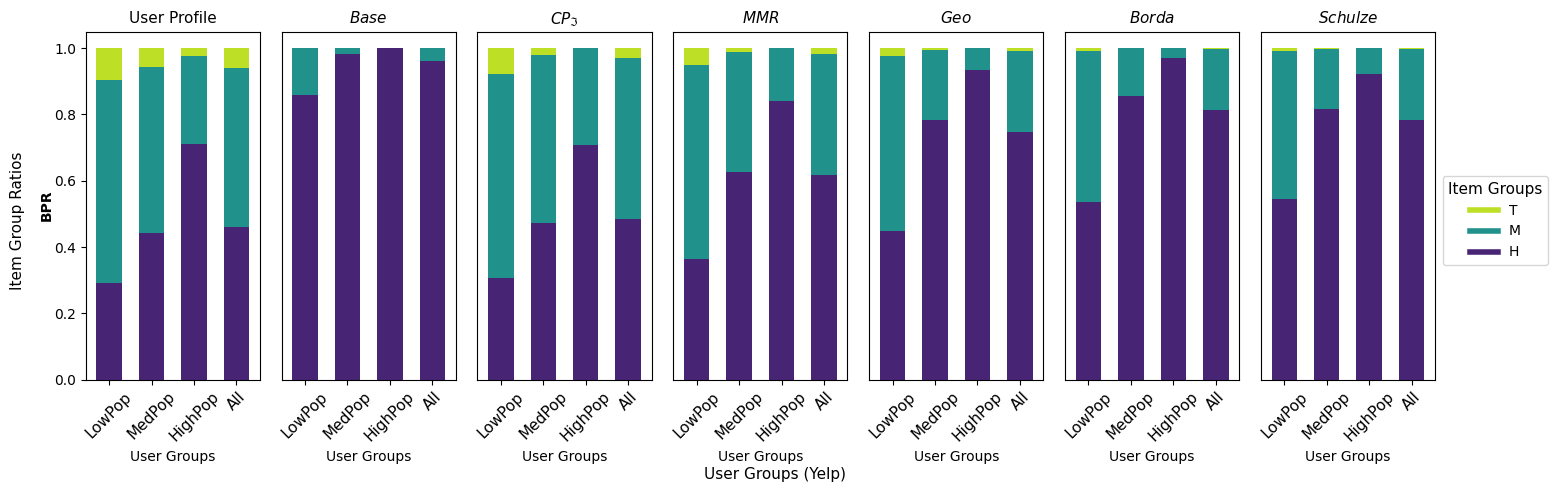

In [28]:
fig, axs = plt.subplots(1, 7, figsize=(15, 5.5))
method_names_for_title = ["$Base$", "$CP_\Im$", "$MMR$", "$Geo$", "$Borda$", "$Schulze$"]

filtered_models = [
    (model_name, methods)
    for model_name, methods in model_dirs.items()
    if model_name not in ["SimpleX", "USG", "plurality", "borda", "cp", "LightGCN", "LORE"]
]

model_name, methods = filtered_models[0]

ax = axs[0]
plot_popularity_distribution(ax, ground_truth_distr, None)
ax.set_title("User Profile", fontsize=11)
ax.set_ylabel(model_name, fontsize=10, weight="bold", labelpad=0)

col = 0
for method_name, json_file in methods.items():
    if method_name in full_eval_methods:
        df = top_k_to_df(json_file, top_k_eval=top_k_eval)
        distr_df = create_pop_distributions(df, item_popularity, user_groups)

        ax = axs[col + 1]
        plot_popularity_distribution(ax, distr_df, None)
        ax.set_title(method_names_for_title[col], fontsize=11)
        col += 1

for ax in axs:
    ax.set_xticks(range(4))
    ax.set_xticklabels(["LowPop", "MedPop", "HighPop", "All"], rotation=45, fontsize=11)

for ax in axs[1:]:
    ax.set_yticks([])

fig.text(0.55, 0.03, f"User Groups ({dataset.capitalize()})", ha="center", fontsize=11)
fig.text(0.04, 0.5, "Item Group Ratios", va="center", rotation="vertical", fontsize=11)

handles = [plt.Line2D([0], [0], color=color, lw=4) for color in plt.cm.viridis([0.9, 0.5, 0.1])]
labels = ["T", "M", "H"]
fig.legend(handles, labels, title="Item Groups", loc="center right", bbox_to_anchor=(1.07, 0.5), ncol=1, title_fontsize=11)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.91])
os.makedirs(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_popularity_distribution_paper.png"), bbox_inches="tight")